# EVALUACIÓN FINAL: ANÁLISIS DE DATOS DE ATLETAS OLÍMPICOS

El Comité Olímpico Internacional ha recopilado información sobre el desempeño de atletas en diversas disciplinas a lo largo de los últimos juegos olímpicos. El objetivo es analizar patrones de rendimiento, identificar factores clave que influyen en el éxito de los atletas y realizar predicciones sobre el desempeño futuro.

**Objetivo**  
Evaluar la capacidad del estudiante para aplicar análisis exploratorio de datos, estadística descriptiva, correlación, regresión lineal y visualización de datos mediante Python y las librerías **Pandas, Seaborn, Matplotlib y Statsmodels**, en el contexto del desempeño de atletas olímpicos en distintas disciplinas deportivas.


## 1. Análisis Exploratorio de Datos (2 puntos)
- Carga el dataset en un DataFrame de Pandas.  
- Muestra las primeras 5 filas y usa `.info()` para obtener información sobre los datos.  
- Calcula estadísticas descriptivas con `.describe()`.  
- Genera un **histograma** del número de entrenamientos semanales.


In [ ]:
# Librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

def tabla(dfx, fmt='fancy_grid', decimals=2, title=None):
    """
    Muestra un DataFrame o Series en formato tabulado con título opcional.
    
    Parámetros:
    dfx : DataFrame o Series
    fmt : str, formato de tabulate (default: 'fancy_grid')
    decimals : int, número de decimales (default: 2)
    title : str, título de la tabla (default: None)
    """
    # Si es Series → convertir a DataFrame
    if isinstance(dfx, pd.Series):
        dfx = dfx.to_frame(name="Valor")

    # Redondear si son datos numéricos
    try:
        dfx = dfx.round(decimals)
    except:
        pass  # ignora si no aplica

    # Imprimir título si existe
    if title:
        print(f"\n {title}\n" + "-" * (len(title) + 2))

    print(tabulate(dfx, headers="keys", tablefmt=fmt))


In [ ]:
# Carga dataset

df=pd.read_csv("olimpicos.csv")

In [140]:
# Exploración inicial

tabla(df.head(5),title="Primeras 5 filas")

print(f"Información inicial del data set:")

df.columns= df.columns.str.replace(" ", "") # Cambio de nombres de columnas
tabla(df.info())

print("\n Dimensiones del DataFrame:", df.shape)

tabla(df.isnull().sum(), title=" Valores nulos:")

tabla(df.describe(),title=" Estadísticas descriptivas:")



 Primeras 5 filas
------------------
╒════╤════════════════╤════════╤═════════════╤═══════════╤═══════════╤════════════════════════════╤════════════════════╤═════════╕
│    │ Atleta         │   Edad │   Altura_cm │   Peso_kg │ Deporte   │   Entrenamientos_Semanales │   Medallas_Totales │ Pais    │
╞════╪════════════════╪════════╪═════════════╪═══════════╪═══════════╪════════════════════════════╪════════════════════╪═════════╡
│  0 │ Usain Bolt     │     34 │         195 │        94 │ Atletismo │                          6 │                  8 │ Jamaica │
├────┼────────────────┼────────┼─────────────┼───────────┼───────────┼────────────────────────────┼────────────────────┼─────────┤
│  1 │ Simone Biles   │     26 │         142 │        47 │ Gimnasia  │                         10 │                  7 │ EE.UU.  │
├────┼────────────────┼────────┼─────────────┼───────────┼───────────┼────────────────────────────┼────────────────────┼─────────┤
│  2 │ Michael Phelps │     35 │         193 

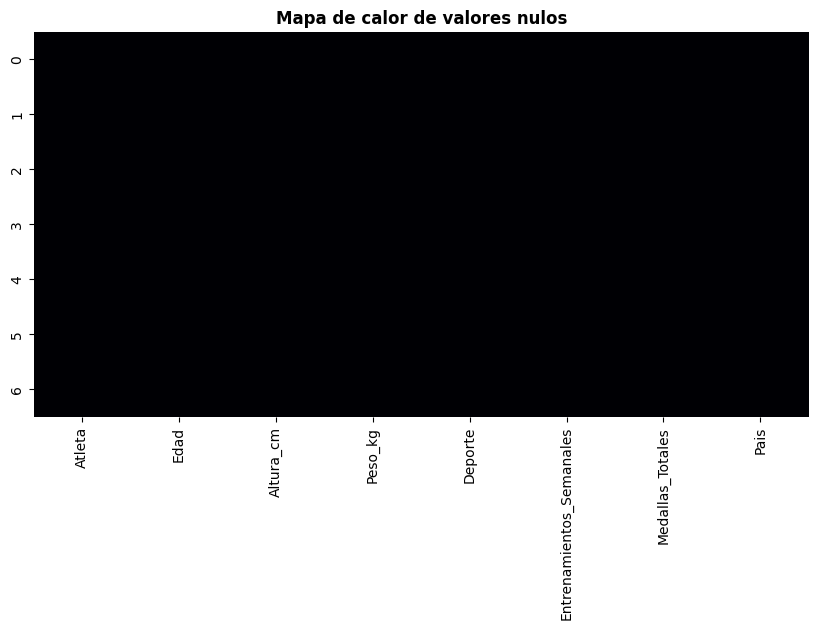

In [ ]:
# Visualización nulos

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=True,
            color=sns.color_palette("viridis")[3])
plt.title("Mapa de calor de valores nulos", fontsize=12, fontweight="bold")
plt.show()

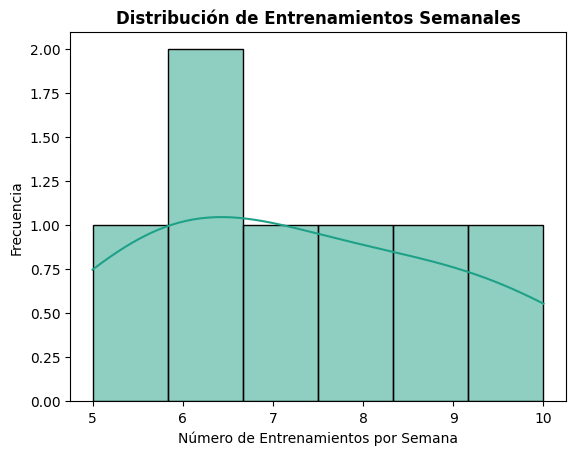

In [60]:
# Histograma de entrenamiento Semanales

sns.histplot(data=df, x='Entrenamientos_Semanales', bins=6, kde=True,
              color=sns.color_palette("viridis")[3])
plt.title("Distribución de Entrenamientos Semanales", fontsize=12, fontweight="bold")
plt.xlabel("Número de Entrenamientos por Semana")
plt.ylabel("Frecuencia")
plt.show()

## 2. Estadística Descriptiva (2 puntos)
- Determina el **tipo de variable** de cada columna.  
- Calcula la **media, mediana y moda** de la cantidad de medallas obtenidas.  
- Calcula la **desviación estándar** de la **altura** de los atletas.  
- Identifica **valores atípicos** en la columna de **peso** utilizando un **boxplot**.


In [141]:
# Tipo de variable de cada columna
tabla(df.dtypes,title="Tipos de variables:")



 Tipos de variables:
---------------------
╒══════════════════════════╤═════════╕
│                          │ Valor   │
╞══════════════════════════╪═════════╡
│ Atleta                   │ object  │
├──────────────────────────┼─────────┤
│ Edad                     │ int64   │
├──────────────────────────┼─────────┤
│ Altura_cm                │ int64   │
├──────────────────────────┼─────────┤
│ Peso_kg                  │ int64   │
├──────────────────────────┼─────────┤
│ Deporte                  │ object  │
├──────────────────────────┼─────────┤
│ Entrenamientos_Semanales │ int64   │
├──────────────────────────┼─────────┤
│ Medallas_Totales         │ int64   │
├──────────────────────────┼─────────┤
│ Pais                     │ object  │
╘══════════════════════════╧═════════╛


In [144]:
# Media, mediana y moda de medallas obtenidas

resumen_medallas = pd.DataFrame({
    "Media":   [df['Medallas_Totales'].mean()],
    "Mediana": [df['Medallas_Totales'].median()],
    "Moda":    [df['Medallas_Totales'].mode()[0]]
})
tabla(resumen_medallas,title="Medallas Obtenidas")



 Medallas Obtenidas
--------------------
╒════╤═════════╤═══════════╤════════╕
│    │   Media │   Mediana │   Moda │
╞════╪═════════╪═══════════╪════════╡
│  0 │    8.57 │         7 │      3 │
╘════╧═════════╧═══════════╧════════╛


In [145]:
# Desviación estándar de la altura
desv_altura = df['Altura_cm'].std()
print(f"\nDesviación estándar de la Altura: {desv_altura:,.2f}")
tabla(df[['Altura_cm']].describe(),title='Estadísticas de la columna "altura"')


Desviación estándar de la Altura: 18.72

 Estadísticas de la columna "altura"
-------------------------------------
╒═══════╤═════════════╕
│       │   Altura_cm │
╞═══════╪═════════════╡
│ count │        7    │
├───────┼─────────────┤
│ mean  │      174.57 │
├───────┼─────────────┤
│ std   │       18.72 │
├───────┼─────────────┤
│ min   │      142    │
├───────┼─────────────┤
│ 25%   │      167    │
├───────┼─────────────┤
│ 50%   │      175    │
├───────┼─────────────┤
│ 75%   │      188    │
├───────┼─────────────┤
│ max   │      195    │
╘═══════╧═════════════╛


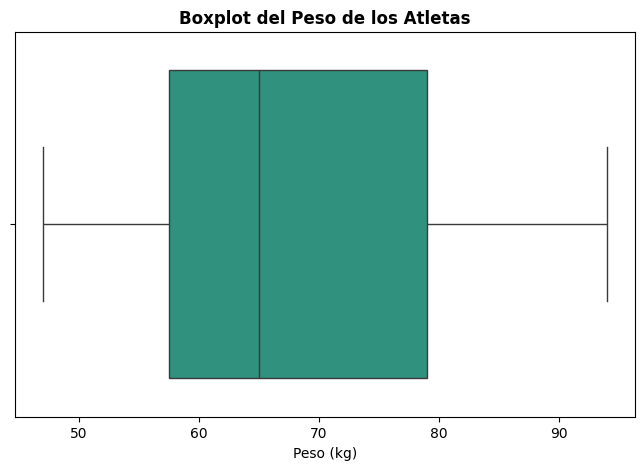

Según el gráfico de bigotes, no existen valores atípicos


In [ ]:
# Identificar valores atípicos en peso con boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Peso_kg', 
            color=sns.color_palette("viridis")[3])
plt.title("Boxplot del Peso de los Atletas", fontsize=12, fontweight="bold")
plt.xlabel("Peso (kg)")
plt.show()

print("Según el gráfico de bigotes, no existen valores atípicos")

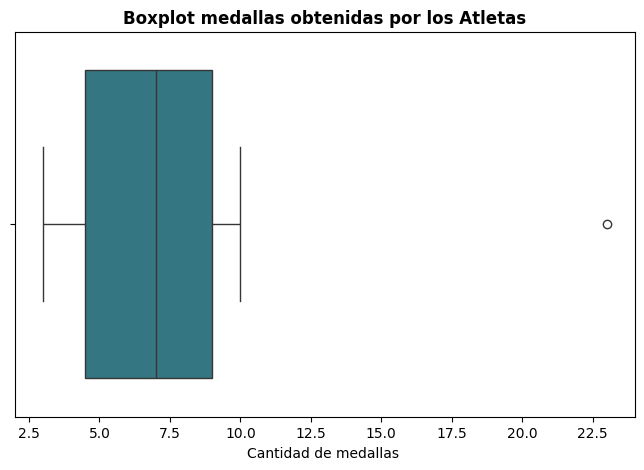

Según el gráfico de bigotes, no existen valores atípicos


In [173]:
# Identificar valores atípicos en medallas con boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Medallas_Totales', 
            color=sns.color_palette("viridis")[2])
plt.title("Boxplot medallas obtenidas por los Atletas", fontsize=12, fontweight="bold")
plt.xlabel("Cantidad de medallas ")
plt.show()

print("Según el gráfico de bigotes, no existen valores atípicos")

## 3. Análisis de Correlación (2 puntos)
- Calcula la **correlación de Pearson** entre **entrenamientos semanales** y **medallas totales**.  
- Crea un **gráfico de dispersión** (*scatterplot*) entre **peso** y **medallas totales** con Seaborn.  
- Explica si existe correlación entre estas variables.


In [148]:
# Seleccionar solo columnas numéricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
df_numerica=df[columnas_numericas]
tabla(df_numerica,title="DataFrame numérica")


 DataFrame numérica
--------------------
╒════╤════════╤═════════════╤═══════════╤════════════════════════════╤════════════════════╕
│    │   Edad │   Altura_cm │   Peso_kg │   Entrenamientos_Semanales │   Medallas_Totales │
╞════╪════════╪═════════════╪═══════════╪════════════════════════════╪════════════════════╡
│  0 │     34 │         195 │        94 │                          6 │                  8 │
├────┼────────┼─────────────┼───────────┼────────────────────────────┼────────────────────┤
│  1 │     26 │         142 │        47 │                         10 │                  7 │
├────┼────────┼─────────────┼───────────┼────────────────────────────┼────────────────────┤
│  2 │     35 │         193 │        88 │                          9 │                 23 │
├────┼────────┼─────────────┼───────────┼────────────────────────────┼────────────────────┤
│  3 │     27 │         183 │        70 │                          8 │                 10 │
├────┼────────┼─────────────┼─────────

In [151]:
# Matriz de Correlación

tabla(df_numerica.corr(),title="Matriz de Correlación completa:")

tabla(df_numerica[['Entrenamientos_Semanales','Medallas_Totales']].corr(),
      title="Matriz de correlación entre entrenamientos semanales y medallas totales")



 Matriz de Correlación completa:
---------------------------------
╒══════════════════════════╤════════╤═════════════╤═══════════╤════════════════════════════╤════════════════════╕
│                          │   Edad │   Altura_cm │   Peso_kg │   Entrenamientos_Semanales │   Medallas_Totales │
╞══════════════════════════╪════════╪═════════════╪═══════════╪════════════════════════════╪════════════════════╡
│ Edad                     │   1    │        0.08 │     -0.08 │                      -0.64 │              -0.27 │
├──────────────────────────┼────────┼─────────────┼───────────┼────────────────────────────┼────────────────────┤
│ Altura_cm                │   0.08 │        1    │      0.94 │                      -0.36 │               0.49 │
├──────────────────────────┼────────┼─────────────┼───────────┼────────────────────────────┼────────────────────┤
│ Peso_kg                  │  -0.08 │        0.94 │      1    │                      -0.2  │               0.56 │
├───────────────────

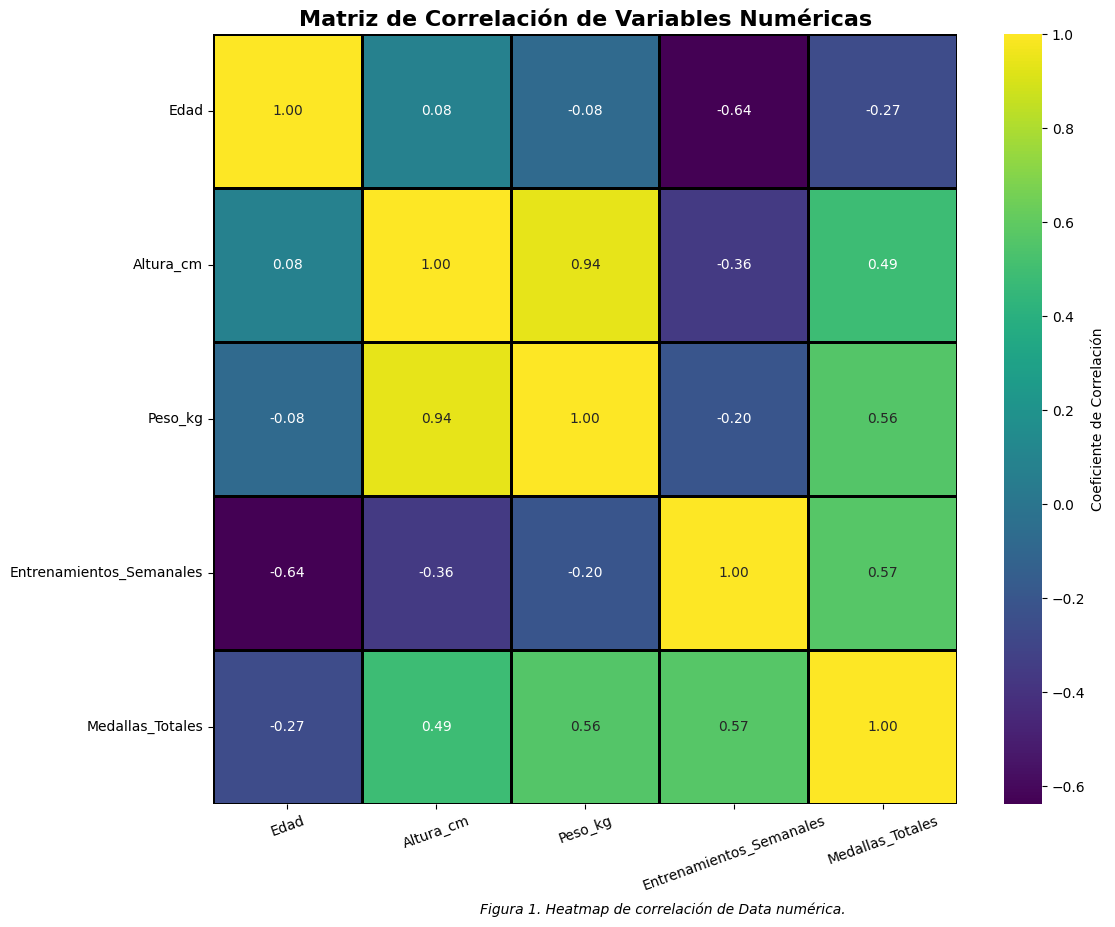

In [171]:
# Heatmap 

# Correlación de 
plt.figure(figsize=(12, 10)) # Ajusta el tamaño del gráfico
sns.heatmap(df_numerica.corr(),
            annot=True,
            cmap='viridis', # Cambiamos el mapa de colores
            fmt=".2f",
            linewidths=1,   # Mayor grosor de líneas
            linecolor='black', # Color de las líneas
            cbar_kws={'label': 'Coeficiente de Correlación'}) # Etiqueta de la barra de color
plt.title('Matriz de Correlación de Variables Numéricas',
           fontsize=16,
           fontweight="bold") # Tamaño del título
plt.xticks(fontsize=10,rotation=20) # Tamaño de las etiquetas del eje X
plt.yticks(fontsize=10, rotation=0) # Tamaño de las etiquetas del eje Y y rotación
# 🔹 Agregar un caption debajo del gráfico
plt.figtext(0.5,0 , "Figura 1. Heatmap de correlación de Data numérica.", 
            wrap=True, ha="center", fontsize=10, style='italic')
plt.show()

In [178]:
print("""Las medallas totales se ven perjudicadas con el paso de la edad, pero no es lógico, 
ya que se debe considerar que a mayor cantidad de años transcurridos el cuerpo se debilita, sin embargo,
no considera que si tiene myor edad, tambien pudo participar en más juegos olímpicos.
La altura y peso tienen una alta correlación, pero esto debería ser ponderado por el deporte que practique
el atleta. 
La cantidad de entrenamientos es altamente importante en las medallas y claza con la lógica.   
      """   
)

Las medallas totales se ven perjudicadas con el paso de la edad, pero no es lógico, 
ya que se debe considerar que a mayor cantidad de años transcurridos el cuerpo se debilita, sin embargo,
no considera que si tiene myor edad, tambien pudo participar en más juegos olímpicos.
La altura y peso tienen una alta correlación, pero esto debería ser ponderado por el deporte que practique
el atleta. 
La cantidad de entrenamientos es altamente importante en las medallas y claza con la lógica.   
      


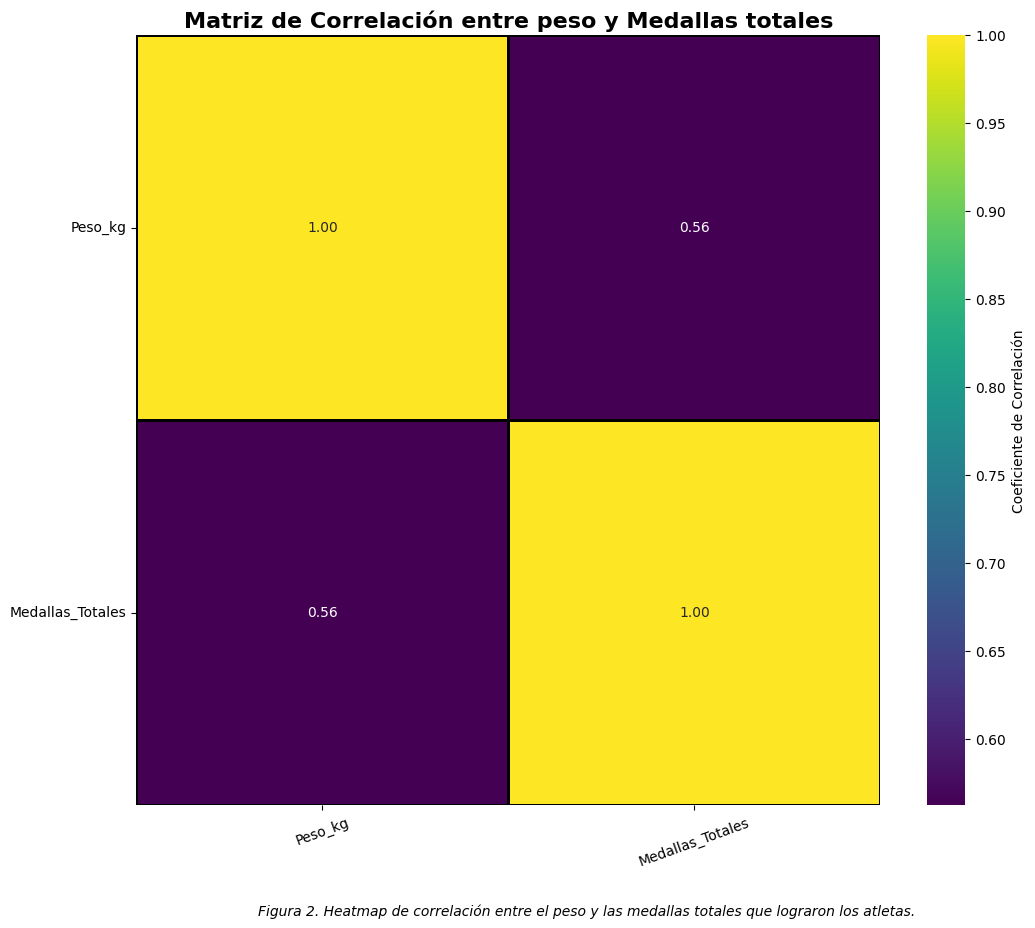

In [170]:
# Heatmap 

# Correlación de peso y medallas totales
plt.figure(figsize=(12, 10)) # Ajusta el tamaño del gráfico
sns.heatmap(df_numerica[['Peso_kg','Medallas_Totales']].corr(),
            annot=True,
            cmap='viridis', # Cambiamos el mapa de colores
            fmt=".2f",
            linewidths=1,   # Mayor grosor de líneas
            linecolor='black', # Color de las líneas
            cbar_kws={'label': 'Coeficiente de Correlación'}) # Etiqueta de la barra de color
plt.title('Matriz de Correlación entre peso y Medallas totales',
           fontsize=16,
           fontweight="bold") # Tamaño del título
plt.xticks(fontsize=10,rotation=20) # Tamaño de las etiquetas del eje X
plt.yticks(fontsize=10, rotation=0) # Tamaño de las etiquetas del eje Y y rotación
# 🔹 Agregar un caption debajo del gráfico
plt.figtext(0.5,0 , "Figura 2. Heatmap de correlación entre el peso y las medallas totales que "
"lograron los atletas.", 
            wrap=True, ha="center", fontsize=10, style='italic')
plt.show()

In [177]:
print("""El peso y la cantidad de medallas totales tienen una alta correlación, sin embargo no creo
que sea tan relevante, ya que se debe considerar que existe un valor altamente atípico que es 
el nadador michael phelps, por ende la tabla de correlación está sesgada
""")

El peso y la cantidad de medallas totales tienen una alta correlación, sin embargo no creo
que sea tan relevante, ya que se debe considerar que existe un valor altamente atípico que es 
el nadador michael phelps, por ende la tabla de correlación está sesgada



## 4. Regresión Lineal (2 puntos)
- Implementa un **modelo de regresión lineal** para predecir el número de medallas obtenidas en función del número de entrenamientos semanales.  
- Obtén los **coeficientes** de regresión e interpreta el resultado.  
- Calcula el **R²** para medir el ajuste del modelo.  
- Usa Seaborn (`regplot`) para graficar la regresión lineal.


## 5. Visualización de Datos con Seaborn y Matplotlib (2 puntos)
- Crea un **heatmap de correlación** entre todas las variables numéricas.  
- Crea un **boxplot** de la **cantidad de medallas por disciplina** deportiva.  
- Personaliza los gráficos con **títulos, etiquetas y colores**.


## INSTRUCCIONES ADICIONALES
- **Puntos totales = 10**.  
- Descarga el material complementario `olimpicos.csv`.  
- Comprime el archivo completo en formato `.zip` o `.rar`.  
- Sube el archivo a la plataforma.
